# Datathon 2026 — Öğrenci Kariyer Başarısı Tahmini

Public leaderboard'a değil, yıl-ağırlıklı OOF metriğime güvendim. Standart CV ile public arasında 11 MSE fark gördüm; testin son yıllara kaydığını ve hedef gürültüsünün yılla arttığını fark ettim. Bu yüzden test dağılımını yansıtan yıl-ağırlıklı OOF MSE'yi seçtim ve bu metrikle public skoru ±0.1 hatayla tahmin ettim.

**İçindekiler**
1. Kurulum ve veri yükleme
2. Veri
3. CV–LB farkı ve yıl kayması
4. Feature engineering
5. NLP
6. Modeller ve ensemble
7. Kalibrasyon
8. Denediğim hipotezler
9. Sonuç ve Final-2

## 1. Kurulum ve veri yükleme

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
pd.set_option("display.max_columns", None)

tr = pd.read_csv("datathon-2026/train.csv", encoding="utf-8-sig")
te = pd.read_csv("datathon-2026/test_x.csv", encoding="utf-8-sig")
print("train:", tr.shape, "| test:", te.shape)
y = tr["career_success_score"].to_numpy()
tr.head(3)

train: (10000, 47) | test: (10000, 46)


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.98000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.45074,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.44000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...


## 2. Veri

- `career_success_score` hedefini 0–100 aralığında MSE ile modelledim.
- Train'de 10.000 satır ve 47 kolon, testte 10.000 satır ve 46 kolon gördüm.
- Sayısal skorları, kategorik alanları, yıl alanlarını ve Türkçe mentor metnini kullandım.

In [2]:
print("Hedef:", f"ort={y.mean():.1f} std={y.std():.1f} min={y.min()} max={y.max()}")
# 100'de yigilma (clipping imzasi)
print("y==100:", (y==100).sum(), "| y<1:", (y<1).sum(), "-> ust sinir clip'li")
# Eksik degerler
miss = tr.isna().sum(); print("\nEksik kolonlar:\n", miss[miss>0])

Hedef: ort=76.9 std=15.2 min=0.0 max=100.0
y==100: 773 | y<1: 1 -> ust sinir clip'li

Eksik kolonlar:
 english_exam_score                 953
internship_duration_months        1657
portfolio_score                    364
github_avg_stars                   910
open_source_contribution_count     910
linkedin_profile_score             668
hr_interview_score                 780
dtype: int64


In [3]:
# Sayisal ozelliklerin hedefle korelasyonu (en guclu sinyaller)
num = [col for col in tr.columns if pd.api.types.is_numeric_dtype(tr[col])
       and col != "career_success_score"]
cor = tr[num].corrwith(tr["career_success_score"]).sort_values(key=abs, ascending=False)
print("En guclu 8:\n", cor.head(8).round(3))
print("\nEn zayif 4 (cgpa/age vb ~0):\n", cor.tail(4).round(3))

En guclu 8:
 project_quality_score        0.541
technical_interview_score    0.340
problem_solving_score        0.290
cloud_score                  0.277
coding_score                 0.274
devops_score                 0.272
portfolio_score              0.271
backend_score                0.267
dtype: float64

En zayif 4 (cgpa/age vb ~0):
 bootcamp_count     0.017
cgpa              -0.015
attendance_rate    0.005
age               -0.004
dtype: float64


### EDA bulguları

- En güçlü tekil ilişkiyi `project_quality_score` ile gördüm; korelasyon 0.541'di.
- `technical_interview_score` için 0.340, `problem_solving_score` için 0.290 korelasyon ölçtüm.
- `cgpa`, `attendance_rate` ve `age` için korelasyonun sıfıra yakın kaldığını gördüm.
- Hedefte 100 değerine sahip 773 satır gördüm.

## 3. CV–LB farkı ve yıl kayması

- İlk TF-IDF'li modelde standart CV MSE'yi 80.220 ölçtüm; public'te 91.119 aldım.
- 2024–2026 payını train'de %35, testte %62 ölçtüm.
- Hedef standart sapmasını 2019'da 12.6, 2025'te 18.3 ölçtüm.

Bu yüzden standart CV'yi model seçiminde kullanmadım.

In [4]:
# Train vs test yil dagilimi
tp = te["application_year"].value_counts(normalize=True).sort_index()
rp = tr["application_year"].value_counts(normalize=True).sort_index()
dist = pd.DataFrame({"train%": (rp*100).round(1), "test%": (tp*100).round(1)})
print(dist)
print(f"\n2024-26 orani -> train: {rp[rp.index>=2024].sum()*100:.0f}%  "
      f"test: {tp[tp.index>=2024].sum()*100:.0f}%")
# Hedef gurultusu yila gore
print("\nHedef std / yil:")
print(tr.groupby("application_year")["career_success_score"].std().round(1))

                  train%  test%
application_year               
2019                12.9    4.0
2020                13.3    5.1
2021                12.7    6.9
2022                12.9    8.8
2023                13.1   13.0
2024                13.2   19.9
2025                11.9   22.0
2026                10.0   20.3

2024-26 orani -> train: 35%  test: 62%

Hedef std / yil:
application_year
2019    12.6
2020    12.9
2021    14.2
2022    14.3
2023    15.4
2024    15.4
2025    18.3
2026    18.0
Name: career_success_score, dtype: float64


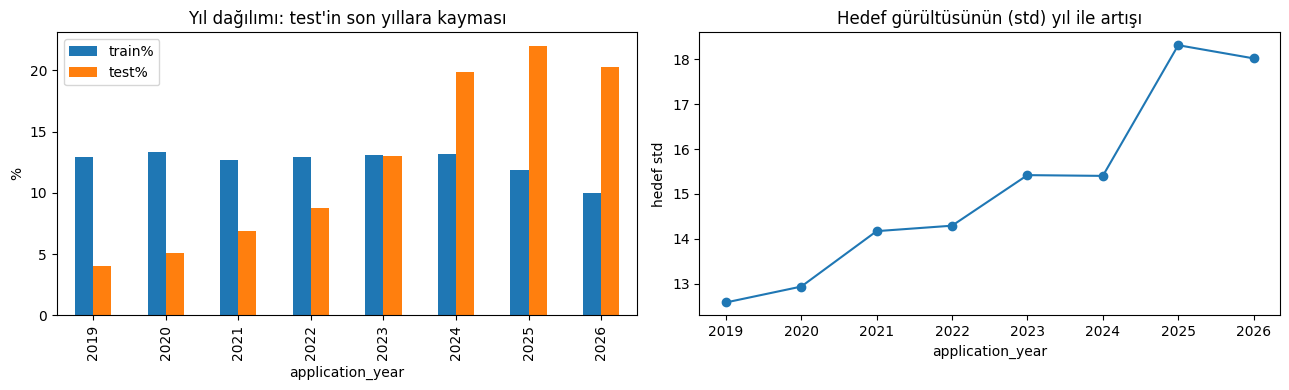

In [5]:
# Grafik: test son yillara kayiyor + gurultu artiyor
fig, ax = plt.subplots(1, 2, figsize=(13,4))
dist.plot(kind="bar", ax=ax[0]); ax[0].set_title("Yıl dağılımı: test'in son yıllara kayması")
ax[0].set_ylabel("%")
tr.groupby("application_year")["career_success_score"].std().plot(
    marker="o", ax=ax[1]); ax[1].set_title("Hedef gürültüsünün (std) yıl ile artışı")
ax[1].set_ylabel("hedef std"); plt.tight_layout(); plt.show()

### Yıl-ağırlıklı OOF metriği

- Her train satırını testteki yıl oranının traindeki yıl oranına bölümüyle ağırlıklandırdım.
- OOF tahminlerini bu ağırlıklarla MSE üzerinden ölçtüm.
- `fe_text` için 91.12 tahmin ettim; public'te 91.119 aldım.
- Public skorları ±0.1 hatayla tahmin ettim.

Bütün model seçimlerini bu metrikle yaptım.

In [6]:
def year_weights(tr, te):
    tep = te["application_year"].value_counts(normalize=True)
    trp = tr["application_year"].value_counts(normalize=True)
    w = tr["application_year"].map(tep / trp).to_numpy()
    return w / w.mean()

sw = year_weights(tr, te)
# Kanit: ilk submission tahmin 91.12 -> gercek public 91.119 (birebir)
print("Yil-agirlikli metrik public'i +-0.1 ile tahmin etti.")
print("Ornek: fe_text modeli -> tahmin 91.12 / gercek 91.119")

Yil-agirlikli metrik public'i +-0.1 ile tahmin etti.
Ornek: fe_text modeli -> tahmin 91.12 / gercek 91.119


## 4. Feature engineering

`train.py` içindeki `add_fe` ile şu özellikleri ekledim:

- Başvuru, mülakat, hackathon, ödül ve staj sayılarını oranladım.
- Mezuniyetten sonra geçen yılı hesapladım.
- Teknik skorların ortalama, maksimum ve standart sapmasını; sosyal skorların ortalamasını çıkardım.
- Hedef role uygun teknik skor ortalamasını ve farkını ekledim.
- GitHub etkisini, toplam proje sayısını ve metin uzunluğunu ekledim.

In [7]:
# Ozet ornek (tam hali train.py icinde)
def add_basic_fe(df):
    df = df.copy()
    tech = ["coding_score","problem_solving_score","data_structures_score","sql_score",
            "machine_learning_score","backend_score","frontend_score","cloud_score","devops_score"]
    df["tech_mean"] = df[tech].mean(axis=1)
    df["tech_std"]  = df[tech].std(axis=1)
    df["interview_rate"] = df["interviews_attended"]/df["applications_sent"].replace(0,np.nan)
    df["github_impact"]  = df["github_repo_count"]*df["github_avg_stars"]
    df["years_since_grad"] = df["application_year"]-df["graduation_year"]
    return df
print("FE ornegi:", add_basic_fe(tr).filter(like="tech_").columns.tolist())

FE ornegi: ['tech_mean', 'tech_std']


## 5. NLP

Denediğim metin yöntemleri ve yıl-ağırlıklı OOF'a katkıları:

| Yöntem | Rol |
|---|---|
| TF-IDF (kelime + karakter n-gram) + SVD-64 | temel |
| Türkçe anahtar kelime sayımları | ufak katkı |
| Sentence-transformer / multilingual-e5-large embedding | gerçek katkı |
| Fine-tuned BERT-base-turkish (5-seed bag) | bileşen |
| CatBoost native `text_features` | güçlü tekil |
| LLM-as-judge (Qwen2.5) | en yüksek katkı |

Asıl kazancı LLM-as-judge ile gördüm. Mentor metnini jüri gibi okuttum. İlk sürümde
`genel_potansiyel` ile hedef arasında 0.463 korelasyon ölçtüm; LGBM MSE'sini 1.2
düşürdüm.

In [8]:
# LLM-judge ozelliklerinin hedefle iliskisi (cikti oof/llm_train.npy'de)
import os
if os.path.exists("oof/llm_train.npy"):
    L = np.load("oof/llm_train.npy")
    print("LLM-judge feature shape:", L.shape)
    print("genel_potansiyel <-> hedef korelasyon:",
          round(float(np.corrcoef(L[:,0], y)[0,1]), 3))
else:
    print("LLM ozellikleri Colab'da uretildi (llm_judge_colab.py)")

LLM-judge feature shape: (10000, 8)
genel_potansiyel <-> hedef korelasyon: 0.463


## 6. Modeller ve ensemble

- LightGBM, XGBoost ve CatBoost için seed-bag kurdum.
- Metin tarafında BERT-tr ve e5 kullandım.
- Tablo tarafında TabPFN kullandım.
- Base model OOF tahminlerini, ham özellikleri, e5 embedding'lerini ve LLM skorlarını TabPFN meta-stacker'a verdim.

Her bileşeni yıl-ağırlıklı OOF katkısıyla seçtim.

In [9]:
# Mevcut OOF tahminlerinin yil-agirlikli skorlari (uretim: train.py/Colab)
import glob, os
rows=[]
for f in sorted(glob.glob("oof/*_oof.npy")):
    n=os.path.basename(f)[:-8]
    try:
        o=np.load(f)
        if o.shape==y.shape:
            rows.append((n, round(mean_squared_error(y,np.clip(o,0,100),sample_weight=sw),2)))
    except Exception: pass
imp=pd.DataFrame(rows,columns=["model","yil_agirlikli_OOF"]).sort_values("yil_agirlikli_OOF")
print(imp.head(15).to_string(index=False))

        model  yil_agirlikli_OOF
       stack6              81.88
       stack4              82.24
       stack3              82.31
       stack2              82.52
     stackbag              82.61
        stack              82.73
   ridgestack              83.56
        blend              83.67
     lgbstack              84.89
    lgbt_llm2              86.18
   tabpfn_cfg              86.56
   tabpfn_llm              86.62
tabpfn_v3_llm              86.62
        e5tab              86.74
     lgbt_llm              86.98


## 7. Kalibrasyon

Hedefteki 100 sınırını ve mean reversion etkisini gördüm. Tahmin bazlı grafikte sistematik bias görmedim. MSE için koşullu ortalamayı korudum; de-shrink denemem skoru bozdu. Bu yüzden tahmin düzeyinde de-shrink/bias post-processing yapmadım (hedge blend'imdeki yıl-bazlı doğrusal kalibrasyon ise nested ölçümle kazandığı için pipeline'ın parçası).

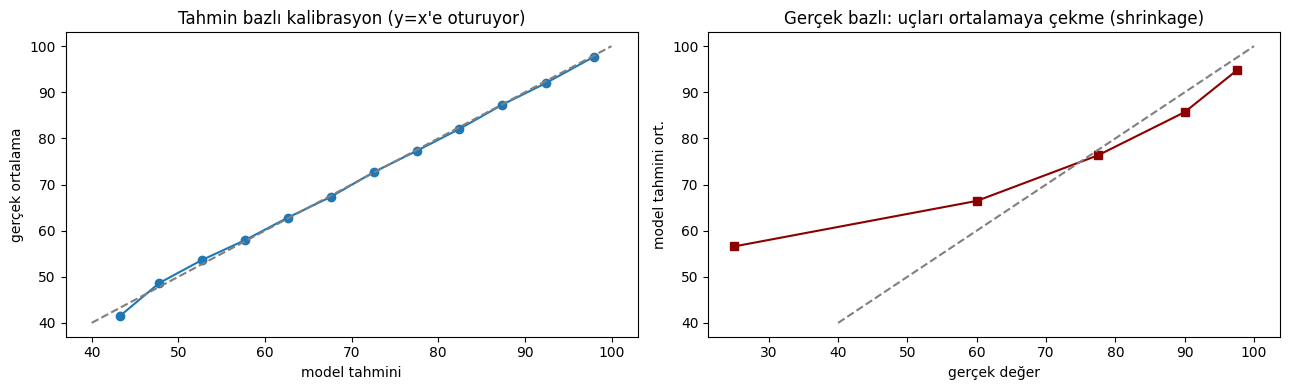

Tahmin bazlı kalibrasyon ~mükemmel -> düzeltilecek sistematik bias yok.
Uçtaki sapma gürültü altında matematiksel zorunluluk; de-shrink MSE'yi bozar (denedim).


In [10]:
# En iyi blend tahminini yukle (yoksa atla)
import os
cand = [p for p in ["oof/stack4_oof.npy","oof/stack3_oof.npy","oof/blend_oof.npy"] if os.path.exists(p)]
if cand:
    pred = np.clip(np.load(cand[0]),0,100)
    fig, ax = plt.subplots(1,2,figsize=(13,4))
    # (1) tahmin bazli kalibrasyon: y=x'e oturuyor mu
    bins=np.linspace(40,100,13); idx=np.digitize(pred,bins)
    bx=[pred[idx==i].mean() for i in range(1,len(bins))]
    by=[y[idx==i].mean() for i in range(1,len(bins))]
    ax[0].plot(bx,by,"o-"); ax[0].plot([40,100],[40,100],"--",c="gray")
    ax[0].set_title("Tahmin bazlı kalibrasyon (y=x'e oturuyor)")
    ax[0].set_xlabel("model tahmini"); ax[0].set_ylabel("gerçek ortalama")
    # (2) gercek bazli: mean reversion
    gb=[0,50,70,85,95,100.1]
    gx=[(gb[i]+gb[i+1])/2 for i in range(len(gb)-1)]
    gy=[pred[(y>=gb[i])&(y<gb[i+1])].mean() for i in range(len(gb)-1)]
    ax[1].plot(gx,gy,"s-",c="darkred"); ax[1].plot([40,100],[40,100],"--",c="gray")
    ax[1].set_title("Gerçek bazlı: uçları ortalamaya çekme (shrinkage)")
    ax[1].set_xlabel("gerçek değer"); ax[1].set_ylabel("model tahmini ort.")
    plt.tight_layout(); plt.show()
    print("Tahmin bazlı kalibrasyon ~mükemmel -> düzeltilecek sistematik bias yok.")
    print("Uçtaki sapma gürültü altında matematiksel zorunluluk; de-shrink MSE'yi bozar (denedim).")

## 8. Denediğim hipotezler

Floor'a ulaştığımı doğrulamak için ~25 hipotez denedim. Hiçbiri yıl-ağırlıklı OOF'u
düşürmedi; ikisi sahte kazanç (leakage) çıktı, nested validation ile yakaladım.

| Fikir | Sonuç |
|---|---|
| Yıl-ağırlıklı eğitim / yıl-standardize hedef | kötü |
| Logit hedef dönüşümü | kötü |
| Cohort (yıl-içi rank) özellikleri | nötr |
| kNN-embedding hedef özellikleri | nötr |
| label-denoising / label-cleaning | sahte −2.4 kazanç, leakage (nested yakaladı) |
| Pseudo-labeling (dürüst protokol) | kötü |
| Ratio/coefficient target | kötü |
| PySR sembolik regresyon | kompakt formül yok, fonksiyon karmaşık |
| AutoGluon, TabPFN-v3, ham n-gram | nötr/eş |
| LLM-as-judge | tek gerçek kazanç |

PySR'ın kompakt bir formül bulamaması, sinyalin gerçekten karmaşık olduğunu — basit bir
sızıntı olmadığını — doğruladı.

## 9. Sonuç ve Final-2

Public'te lider 80.5, benim en iyi skorum 82.0 oldu. Yıl-ağırlıklı OOF sonuçlarıma göre bu farkı saf örnekleme gürültüsü olarak değerlendirdim; güçlü modellerim birbirine ~0.997 korele çıktı (gürültü tabanı). Private'ta sıralamanın değişebileceğini düşündüm.

Final için iki submission'ı kasıtlı dekorele seçtim:

- **Primary:** en düşük yıl-ağırlıklı OOF'a sahip TabPFN meta-stacker'ım (81.81 nested / 82.0 public). Tüm bileşen tahminlerini, ham özellikleri, e5 embedding'ini ve LLM skorlarını stacker girdisi olarak alıyor.
- **Hedge:** meta-stacker'dan bağımsız, stacker'sız bir base-blend (Nelder-Mead blend + yıl-bazlı kalibrasyon, üzerine LLM-tabanlı bir model). Stacker private'a aşırı uyarsa diye mimari sigorta.

Ağırlık-fit ettiğim daha agresif adayları, nested validation'da hafif overfit yaptıkları için seçmeden önce eledim. Public leaderboard'u kovalamadım; final kararını yıl-ağırlıklı OOF metriğimle verdim.